In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import json
import urllib.request
import plotly.express as px

In [2]:
# CONFIGURATION, COLORS, AND THEME
LYFT_PINK = '#FF00BF'
SECTION_BLUE = '#1A73E8'
LIGHT_GRAY = '#F5F5F5'
UBER_BLACK = '#000000'

sns.set_theme(style="whitegrid")
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=[LYFT_PINK, SECTION_BLUE])

In [3]:
# LOAD & CLEAN DATA
df = pd.read_csv('rideshare_kaggle.csv')

# Drop rows where price is missing
df_clean = df[df['price'].notna()].copy()

# Feature Engineering
df_clean['is_surge'] = (df_clean['surge_multiplier'] > 1).astype(int)
df_clean['price_per_mile'] = df_clean['price'] / df_clean['distance']

# Focus on Lyft for Section 1
lyft_df = df_clean[df_clean['cab_type'] == 'Lyft'].copy()
lyft_df['datetime'] = pd.to_datetime(lyft_df['datetime'])
lyft_df['hour'] = lyft_df['datetime'].dt.hour
lyft_df['hour_bin'] = lyft_df['datetime'].dt.floor('H')

C:\Users\irone\AppData\Local\Temp\ipykernel_36300\3835788165.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  lyft_df['hour_bin'] = lyft_df['datetime'].dt.floor('H')


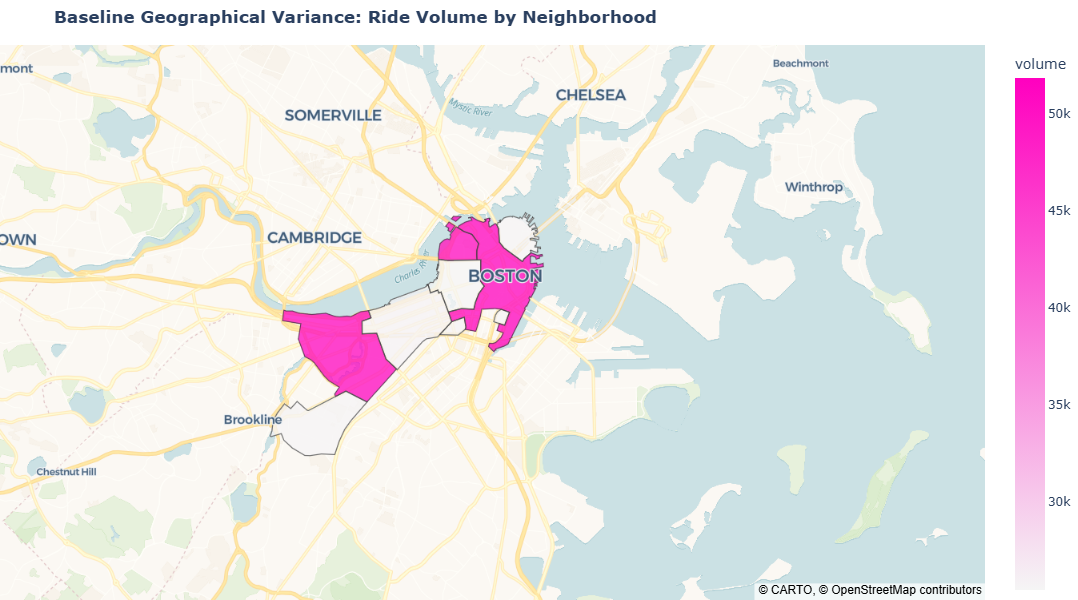

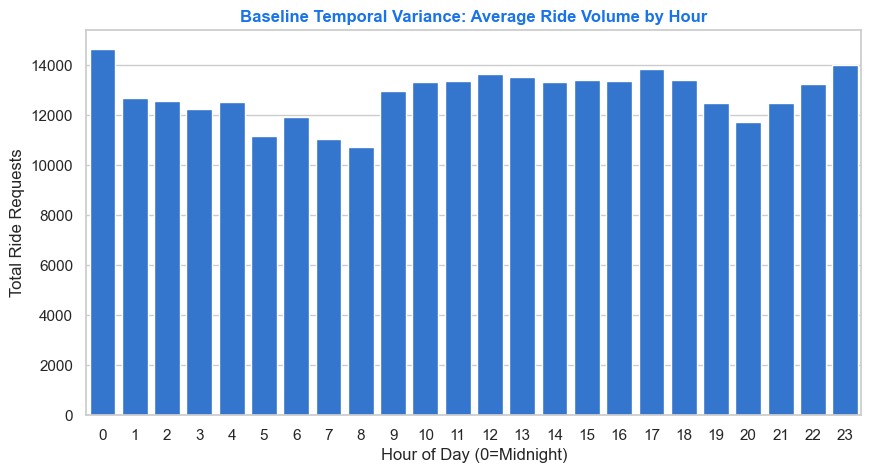

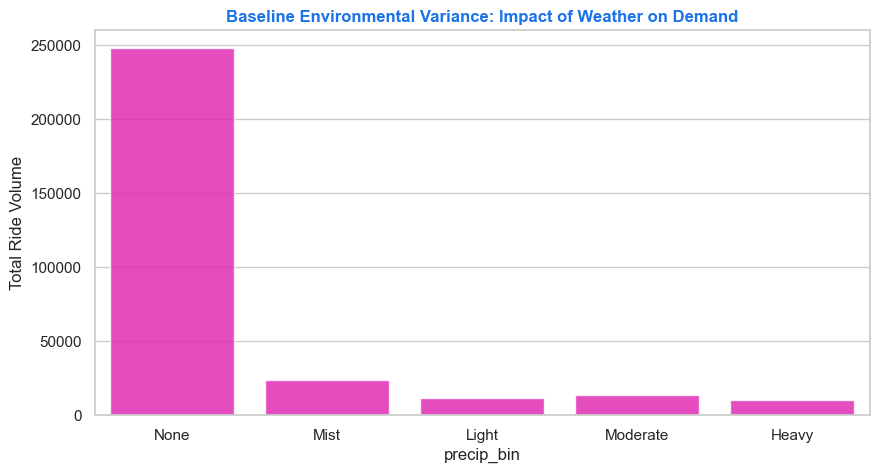

In [4]:
# BASELINE VISUALIZATIONS

# GEOGRAPHICAL VARIANCE: Ride Volume Mapped
GEOJSON_URL = "https://raw.githubusercontent.com/blackmad/neighborhoods/master/boston.geojson"
with urllib.request.urlopen(GEOJSON_URL, timeout=60) as resp:
    boston_geojson = json.load(resp)

SOURCE_TO_NBHD = {
    "Back Bay": "Back Bay", "Beacon Hill": "Beacon Hill", "Boston University": "Fenway",
    "Fenway": "Fenway", "Financial District": "Downtown", "Haymarket Square": "Downtown",
    "North End": "North End", "North Station": "West End", "Northeastern University": "Mission Hill",
    "South Station": "Leather District", "Theatre District": "Bay Village", "West End": "West End",
}

geo_demand = lyft_df.groupby("source", as_index=False).agg(volume=("id", "count"))
geo_demand["neighborhood"] = geo_demand["source"].map(SOURCE_TO_NBHD)
geo_final = geo_demand.groupby("neighborhood", as_index=False).agg({"volume": "sum"})

fig_map = px.choropleth_map(
    geo_final, geojson=boston_geojson, locations="neighborhood",
    featureidkey="properties.name", color="volume", 
    color_continuous_scale=[LIGHT_GRAY, LYFT_PINK], # Lyft theme for map
    zoom=11.5, center={"lat": 42.35, "lon": -71.06}, opacity=0.75, height=600,
    title="<b>Baseline Geographical Variance: Ride Volume by Neighborhood</b>"
)
fig_map.update_layout(margin=dict(r=0, t=45, l=0, b=0))
fig_map.show()
# Note: fig_map.write_image("baseline_geo_map.png") requires kaleido installed

# TEMPORAL VARIANCE: Avg Volume by Hour (0-24)
hourly_vol = lyft_df.groupby('hour')['id'].count()
plt.figure(figsize=(10, 5))
sns.barplot(x=hourly_vol.index, y=hourly_vol.values, color=SECTION_BLUE)
plt.title('Baseline Temporal Variance: Average Ride Volume by Hour', fontweight='bold', color=SECTION_BLUE)
plt.xlabel('Hour of Day (0=Midnight)')
plt.ylabel('Total Ride Requests')
plt.savefig('baseline_temporal_variance.png', dpi=300, bbox_inches='tight')
plt.show()

# ENVIRONMENTAL VARIANCE: Ride Volume by Weather (Fixed Bins)
lyft_df['precip_bin'] = pd.cut(
    lyft_df['precipIntensity'], 
    bins=[-0.1, 0.001, 0.01, 0.05, 0.1, 2.0], 
    labels=['None', 'Mist', 'Light', 'Moderate', 'Heavy'],
    include_lowest=True
)
precip_vol = lyft_df.groupby('precip_bin', observed=True)['id'].count()

plt.figure(figsize=(10, 5))
sns.barplot(x=precip_vol.index, y=precip_vol.values, color=LYFT_PINK, alpha=0.8)
plt.title('Baseline Environmental Variance: Impact of Weather on Demand', fontweight='bold', color=SECTION_BLUE)
plt.ylabel('Total Ride Volume')
plt.savefig('baseline_environmental_variance.png', dpi=300, bbox_inches='tight')
plt.show()

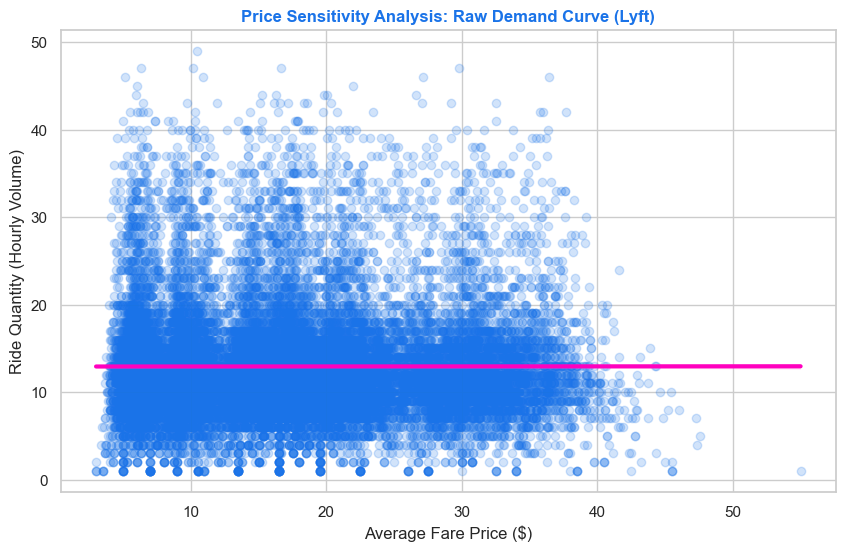

In [5]:
# PRICE SENSITIVITY VISUALIZED

demand_agg = lyft_df.groupby(['hour_bin', 'source', 'name']).agg({
    'id': 'count', 'price': 'mean', 'distance': 'mean', 
    'temperature': 'mean', 'precipIntensity': 'mean', 'is_surge': 'max'
}).rename(columns={'id': 'ride_volume'}).reset_index()

plt.figure(figsize=(10, 6))
sns.regplot(data=demand_agg, x='price', y='ride_volume', 
            scatter_kws={'alpha':0.2, 'color':SECTION_BLUE}, 
            line_kws={'color':LYFT_PINK, 'lw':3})
plt.title('Price Sensitivity Analysis: Raw Demand Curve (Lyft)', fontsize=12, fontweight='bold', color=SECTION_BLUE)
plt.xlabel('Average Fare Price ($)')
plt.ylabel('Ride Quantity (Hourly Volume)')
plt.savefig('price_sensitivity_demand_curve.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
# ECONOMETRIC MODELING PREP

# Log-Log and Lag preparation
demand_agg = demand_agg.sort_values(by=['source', 'name', 'hour_bin'])
demand_agg['log_volume'] = np.log(demand_agg['ride_volume'])
demand_agg['log_price'] = np.log(demand_agg['price'])
demand_agg['log_price_lagged'] = demand_agg.groupby(['source', 'name'])['log_price'].shift(1)

iv_data = demand_agg.dropna(subset=['log_price_lagged']).copy()
iv_data_final = pd.get_dummies(iv_data, columns=['source', 'name'], drop_first=True)

fe_cols = [col for col in iv_data_final.columns if 'source_' in col or 'name_' in col]
exog_base = ['distance', 'temperature']

In [7]:
# MODELING BLOCK 1: WITHOUT IS_SURGE

print("\nBLOCK 1: MODELING WITHOUT SURGE CONTROL\n")

# OLS (Log-Log)
X_ols_1 = sm.add_constant(iv_data_final[['log_price'] + exog_base + ['precipIntensity']])
ols_1 = sm.OLS(iv_data_final['log_volume'], X_ols_1.astype(float)).fit()
print("\n OLS Regression Results ")
print(ols_1.summary().tables[1])

# IV Regression (Lagged Price)
X_s1_1 = sm.add_constant(iv_data_final[['log_price_lagged'] + exog_base + fe_cols])
s1_1 = sm.OLS(iv_data_final['log_price'], X_s1_1.astype(float)).fit()
iv_data_final['price_hat_1'] = s1_1.predict(X_s1_1)

X_s2_1_cols = ['price_hat_1'] + exog_base + fe_cols
X_s2_1 = sm.add_constant(iv_data_final[X_s2_1_cols])
s2_1 = sm.OLS(iv_data_final['log_volume'], X_s2_1.astype(float)).fit()

print("\n IV 2SLS Results (Lagged Price Instrument) ")
print(s2_1.summary().tables[1])
print(f"Elasticity (without Surge Control): {s2_1.params['price_hat_1']:.4f}")


BLOCK 1: MODELING WITHOUT SURGE CONTROL


 OLS Regression Results 
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               2.2788      0.024     94.622      0.000       2.232       2.326
log_price           0.0048      0.005      0.877      0.381      -0.006       0.016
distance            0.0035      0.005      0.681      0.496      -0.007       0.014
temperature         0.0035      0.000      8.018      0.000       0.003       0.004
precipIntensity     2.6661      0.129     20.648      0.000       2.413       2.919

 IV 2SLS Results (Lagged Price Instrument) 
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                              0.3540      1.744      0.203      0.839      -3.064       3.772
pr

In [8]:
# MODELING BLOCK 2: WITH IS_SURGE

print("\n BLOCK 2: MODELING WITH SURGE REGIME CONTROL\n" )

# OLS (Log-Log)
X_ols_2 = sm.add_constant(iv_data_final[['log_price'] + exog_base + ['precipIntensity', 'is_surge']])
ols_2 = sm.OLS(iv_data_final['log_volume'], X_ols_2.astype(float)).fit()
print("\n OLS Regression Results (Including is_surge) ")
print(ols_2.summary().tables[1])

# IV Regression (Lagged Price)
# In Step 1, we include is_surge as a control
X_s1_2 = sm.add_constant(iv_data_final[['log_price_lagged'] + exog_base + fe_cols + ['is_surge']])
s1_2 = sm.OLS(iv_data_final['log_price'], X_s1_2.astype(float)).fit()
iv_data_final['price_hat_2'] = s1_2.predict(X_s1_2)

X_s2_2_cols = ['price_hat_2'] + exog_base + fe_cols + ['is_surge']
X_s2_2 = sm.add_constant(iv_data_final[X_s2_2_cols])
s2_2 = sm.OLS(iv_data_final['log_volume'], X_s2_2.astype(float)).fit()

print("\n IV 2SLS Results (Including is_surge) ")
print(s2_2.summary().tables[1])
print(f"Elasticity (with Surge Control): {s2_2.params['price_hat_2']:.4f}")


 BLOCK 2: MODELING WITH SURGE REGIME CONTROL


 OLS Regression Results (Including is_surge) 
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               2.4241      0.024    101.781      0.000       2.377       2.471
log_price          -0.0706      0.006    -12.283      0.000      -0.082      -0.059
distance           -0.0190      0.005     -3.716      0.000      -0.029      -0.009
temperature         0.0034      0.000      7.942      0.000       0.003       0.004
precipIntensity     2.5550      0.126     20.303      0.000       2.308       2.802
is_surge            0.2328      0.007     35.607      0.000       0.220       0.246

 IV 2SLS Results (Including is_surge) 
                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------